In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
import numpy as np

In [8]:
df=pd.read_csv("Promedio_edad.csv")

In [9]:
df.head(5)

,Mundial,Campeon,Prom_edad
0,Mexico 1986,Argentina,25.9
1,Italia 1990,Alemania,27.3
2,USA 1994,Brasil,27.0
3,Francia 1998,Francia,26.7
4,Cor/Jap 2002,Brasil,26.2


In [10]:
#Crear numevo indice para hacer mas facil la grafica 
df["Identificador"] = df["Campeon"] + " (" + df["Mundial"] + ")"

In [11]:
#Comprobación del nuevo df
df.tail(3)

,Mundial,Campeon,Prom_edad,Identificador
7,Brasil 2014,Alemania,25.7,Alemania (Brasil 2014)
8,Rusia 2018,Francia,25.6,Francia (Rusia 2018 )
9,Qatar 2022,Argentina,27.5,Argentina (Qatar 2022)


In [12]:
# Ordenamos el DataFrame de mayor a menor edad para un análisis visual más limpio
df = df.sort_values(by="Prom_edad", ascending=False).reset_index(drop=True)

In [13]:
df

,Mundial,Campeon,Prom_edad,Identificador
0,Alemania 2006,Italia,28.2,Italia (Alemania 2006)
1,Qatar 2022,Argentina,27.5,Argentina (Qatar 2022)
2,Italia 1990,Alemania,27.3,Alemania (Italia 1990)
3,USA 1994,Brasil,27.0,Brasil (USA 1994)
4,Francia 1998,Francia,26.7,Francia (Francia 1998)
5,Cor/Jap 2002,Brasil,26.2,Brasil (Cor/Jap 2002)
6,Mexico 1986,Argentina,25.9,Argentina (Mexico 1986)
7,Sudafrica 2010,España,25.9,España (Sudafrica 2010)
8,Brasil 2014,Alemania,25.7,Alemania (Brasil 2014)
9,Rusia 2018,Francia,25.6,Francia (Rusia 2018 )


In [14]:
#  Configuración estética de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [15]:
Edad_moderna=df["Prom_edad"].mean()
Edad_moderna

np.float64(26.6)

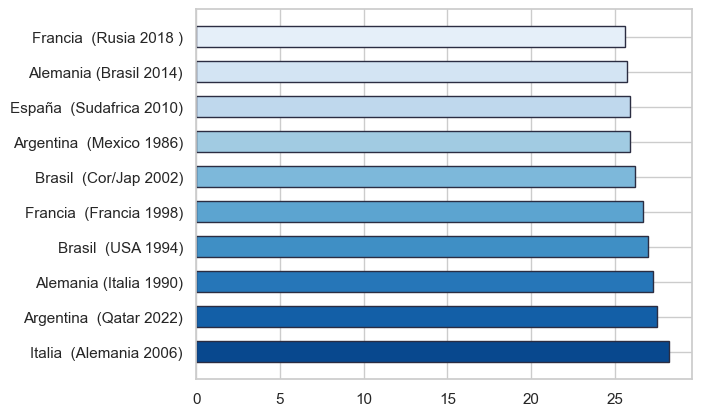

In [17]:
paleta = sns.color_palette("Blues_r", n_colors=len(df))

barras = plt.barh(
    df["Identificador"],
    df["Prom_edad"],
    color=paleta,
    edgecolor="#2b2d42",
    height=0.6,
)

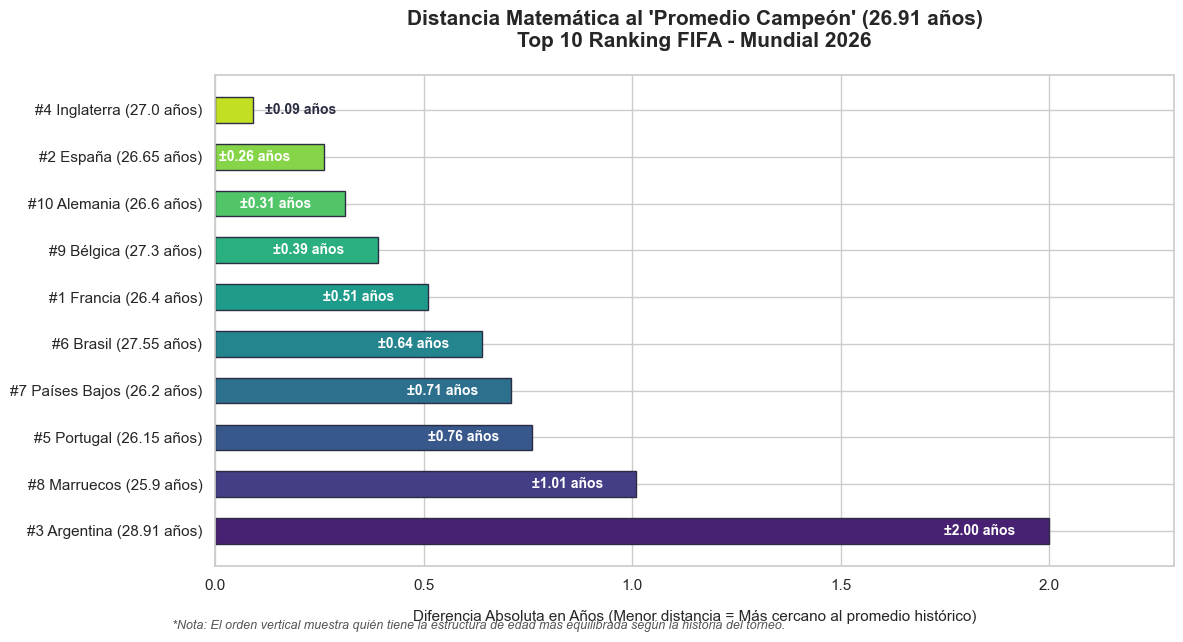

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Limpiar memoria y forzar que la gráfica salga en línea
plt.clf()
plt.close("all")

# 2. Datos
datos_top_10 = {
    "Ranking": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Selección": [
        "Francia",
        "España",
        "Argentina",
        "Inglaterra",
        "Portugal",
        "Brasil",
        "Países Bajos",
        "Marruecos",
        "Bélgica",
        "Alemania",
    ],
    "Edad_2026": [
        26.40,
        26.65,
        28.91,
        27.00,
        26.15,
        27.55,
        26.20,
        25.90,
        27.30,
        26.60,
    ],
}

PROMEDIO_CAMPEON = 26.91
df_top10 = pd.DataFrame(datos_top_10)
df_top10["Desviación"] = (df_top10["Edad_2026"] - PROMEDIO_CAMPEON).abs()
df_top10 = df_top10.sort_values(by="Desviación", ascending=True).reset_index(
    drop=True
)

df_top10["Etiqueta"] = (
    "#"
    + df_top10["Ranking"].astype(str)
    + " "
    + df_top10["Selección"]
    + " ("
    + df_top10["Edad_2026"].astype(str)
    + " años)"
)

# 3. Configuración del lienzo (¡TODO JUNTO AQUÍ!)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# Usamos la paleta corregida de Seaborn
paleta = sns.color_palette("viridis_r", n_colors=len(df_top10))

# 4. Trazar barras
barras = ax.barh(
    df_top10["Etiqueta"],
    df_top10["Desviación"],
    color=paleta,
    edgecolor="#2b2d42",
    height=0.55,
)
ax.invert_yaxis()

# 5. Añadir textos a las barras
for barra in barras:
    ancho = barra.get_width()
    pos_x = ancho + 0.03 if ancho < 0.1 else ancho - 0.08
    color_texto = "#2b2d42" if ancho < 0.1 else "white"
    ax.text(
        pos_x,
        barra.get_y() + barra.get_height() / 2,
        f"±{ancho:.2f} años",
        va="center",
        ha="left" if ancho < 0.1 else "right",
        color=color_texto,
        weight="bold",
        fontsize=10,
    )

# 6. Personalización de títulos y etiquetas
ax.set_title(
    "Distancia Matemática al 'Promedio Campeón' (26.91 años)\nTop 10 Ranking FIFA - Mundial 2026",
    fontsize=15,
    weight="bold",
    pad=20,
)
ax.set_xlabel(
    "Diferencia Absoluta en Años (Menor distancia = Más cercano al promedio histórico)",
    fontsize=11,
    labelpad=12,
)
ax.set_xlim(0, 2.3)

plt.figtext(
    0.15,
    0.02,
    "*Nota: El orden vertical muestra quién tiene la estructura de edad más equilibrada según la historia del torneo.",
    fontsize=9,
    style="italic",
    color="#555555",
)

plt.tight_layout()

# 7. Desplegar
plt.show()

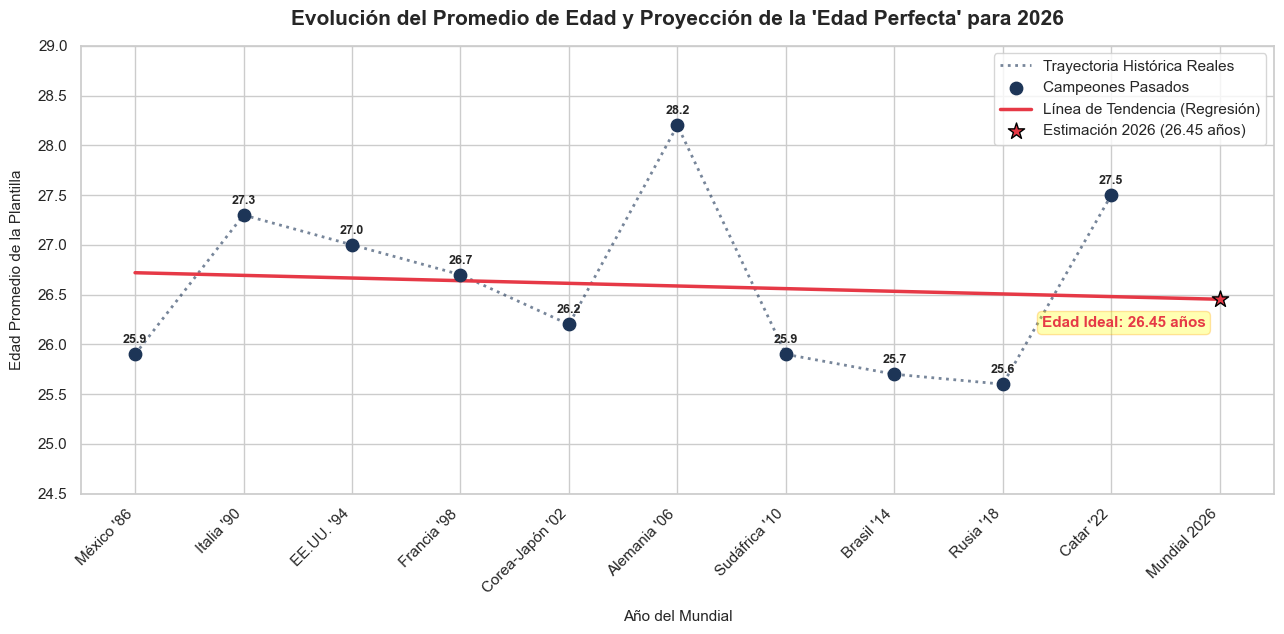

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar el entorno de gráficos
plt.clf()
plt.close("all")

# 2. Reconstruir la base de datos cronológica de los últimos 10 mundiales
datos_cronologicos = {
    "Año": [1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022],
    "Mundial": [
        "México '86",
        "Italia '90",
        "EE.UU. '94",
        "Francia '98",
        "Corea-Japón '02",
        "Alemania '06",
        "Sudáfrica '10",
        "Brasil '14",
        "Rusia '18",
        "Catar '22",
    ],
    "Edad": [25.9, 27.3, 27.0, 26.7, 26.2, 28.2, 25.9, 25.7, 25.6, 27.5],
}

df_tiempo = pd.DataFrame(datos_cronologicos)

# 3. Calcular la Línea de Tendencia Matemática (Regresión Lineal)
# Ajustamos un polinomio de grado 1: y = mx + b
m, b = np.polyfit(df_tiempo["Año"], df_tiempo["Edad"], 1)

# Proyectar el valor estimado para el Mundial de este año (2026)
anio_proyeccion = 2026
edad_proyectada_2026 = m * anio_proyeccion + b

# Crear un set de años extendido hasta 2026 para dibujar la línea continua
anios_linea = np.append(df_tiempo["Año"].values, anio_proyeccion)
valores_tendencia = m * anios_linea + b

# 4. Configuración estética de la gráfica
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 6.5))

# Graficar los datos históricos reales (Línea + Puntos)
ax.plot(
    df_tiempo["Año"],
    df_tiempo["Edad"],
    color="#1d3557",
    linewidth=2,
    linestyle=":",
    alpha=0.6,
    label="Trayectoria Histórica Reales",
)
ax.scatter(
    df_tiempo["Año"],
    df_tiempo["Edad"],
    color="#1d3557",
    s=80,
    zorder=3,
    label="Campeones Pasados",
)

# Graficar la línea de tendencia extendida hasta 2026
ax.plot(
    anios_linea,
    valores_tendencia,
    color="#e63946",
    linewidth=2.5,
    label="Línea de Tendencia (Regresión)",
)

# Resaltar el punto estimado para 2026
ax.scatter(
    anio_proyeccion,
    edad_proyectada_2026,
    color="#e63946",
    s=150,
    marker="*",
    edgecolor="black",
    zorder=4,
    label=f"Estimación 2026 ({edad_proyectada_2026:.2f} años)",
)

# 5. Anotaciones de texto sobre los puntos clave
for i, txt in enumerate(df_tiempo["Edad"]):
    ax.annotate(
        f"{txt}",
        (df_tiempo["Año"][i], df_tiempo["Edad"][i]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        weight="bold",
    )

# Etiqueta especial para la estrella de la predicción 2026
ax.annotate(
    f"Edad Ideal: {edad_proyectada_2026:.2f} años",
    (anio_proyeccion, edad_proyectada_2026),
    textcoords="offset points",
    xytext=(-10, -20),
    ha="right",
    fontsize=11,
    weight="bold",
    color="#e63946",
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3, ec="orange"),
)

# 6. Personalizar Ejes y Etiquetas
ax.set_title(
    "Evolución del Promedio de Edad y Proyección de la 'Edad Perfecta' para 2026",
    fontsize=15,
    weight="bold",
    pad=15,
)
ax.set_xlabel("Año del Mundial", fontsize=11, labelpad=10)
ax.set_ylabel("Edad Promedio de la Plantilla", fontsize=11, labelpad=10)

# Forzar que el eje X muestre los años de los mundiales + el actual de forma limpia
ax.set_xticks(anios_linea)
ax.set_xticklabels(
    list(df_tiempo["Mundial"]) + ["Mundial 2026"], rotation=45, ha="right"
)
ax.set_ylim(24.5, 29)

# Mostrar leyenda explicativa
ax.legend(loc="upper right", frameon=True, facecolor="white")

plt.tight_layout()

# 7. Desplegar gráfico completo
plt.show()

In [39]:
import pandas as pd

# 1. Diccionario con los datos del mundial
datos_mundial = {
    "Selección": [
        "Alemania",
        "Arabia Saudita",
        "Argelia",
        "Argentina",
        "Australia",
        "Austria",
        "Bélgica",
        "Brasil",
        "Camerún",
        "Canadá",
        "Chile",
        "Colombia",
        "Corea del Sur",
        "Costa de Marfil",
        "Costa Rica",
        "Croacia",
        "Dinamarca",
        "Ecuador",
        "Egipto",
        "Escocia",
        "España",
        "Estados Unidos",
        "Francia",
        "Ghana",
        "Países Bajos",
        "Hungría",
        "Inglaterra",
        "Irán",
        "Irak",
        "Italia",
        "Japón",
        "Marruecos",
        "México",
        "Nigeria",
        "Nueva Zelanda",
        "Panamá",
        "Paraguay",
        "Perú",
        "Polonia",
        "Portugal",
        "Qatar",
        "República Checa",
        "Senegal",
        "Serbia",
        "Suiza",
        "Túnez",
        "Turquía",
        "Uruguay",
    ],
    "Edad": [
        26.60,
        26.97,
        27.84,
        28.91,
        27.10,
        26.85,
        27.30,
        27.55,
        26.45,
        26.10,
        27.40,
        29.98,
        28.15,
        25.48,
        25.95,
        28.40,
        27.65,
        25.80,
        28.30,
        27.90,
        26.65,
        25.85,
        26.40,
        25.60,
        26.20,
        27.15,
        27.00,
        29.10,
        26.35,
        26.95,
        27.25,
        25.90,
        27.23,
        26.15,
        25.70,
        27.60,
        26.90,
        28.85,
        27.50,
        26.15,
        28.20,
        26.30,
        28.10,
        27.45,
        28.25,
        27.05,
        25.85,
        26.25,
    ],
}

# 2. Crear DataFrame
df_mundial = pd.DataFrame(datos_mundial)

# 3. Definir el objetivo y calcular la diferencia absoluta
OBJETIVO = 26.45
df_mundial["Distancia"] = (df_mundial["Edad"] - OBJETIVO).abs()

# 4. Filtrar las 10 más cercanas ordenando de menor a mayor distancia
top_10_cercanas = df_mundial.sort_values(by="Distancia").head(10)

# Ver el resultado en tu terminal o notebook
print(top_10_cercanas.to_string(index=False))

      Selección  Edad  Distancia
        Camerún 26.45       0.00
        Francia 26.40       0.05
           Irak 26.35       0.10
República Checa 26.30       0.15
       Alemania 26.60       0.15
         España 26.65       0.20
        Uruguay 26.25       0.20
   Países Bajos 26.20       0.25
       Portugal 26.15       0.30
        Nigeria 26.15       0.30


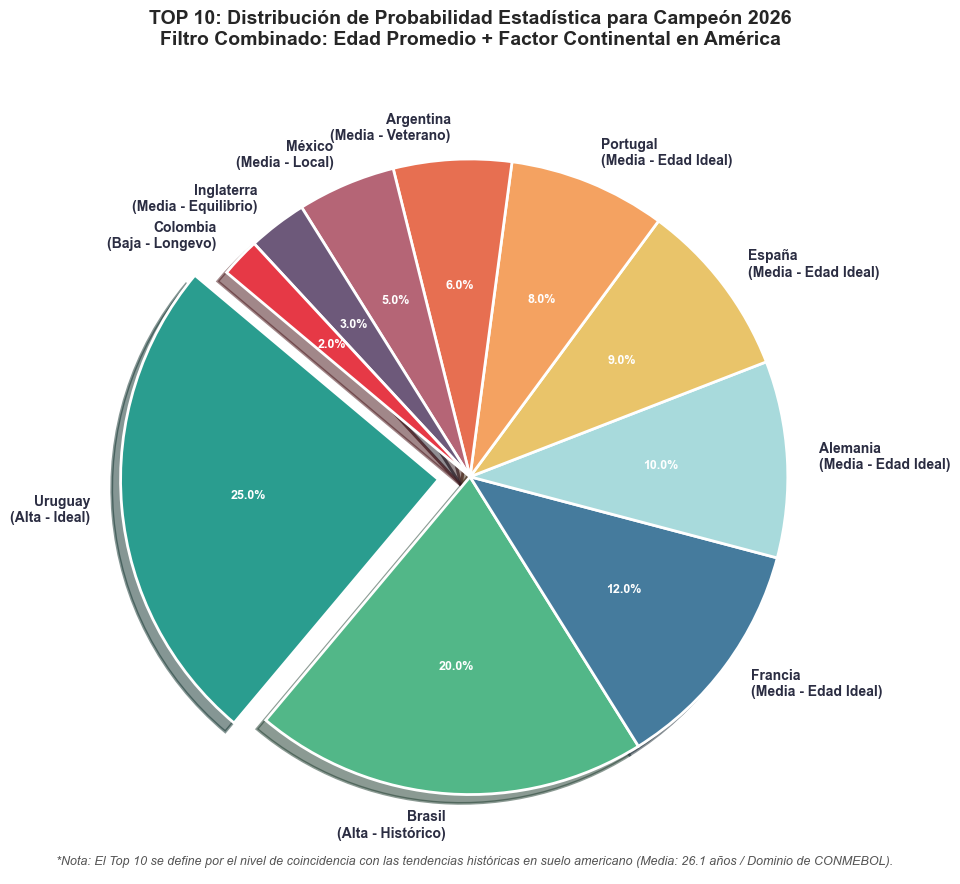

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpiar el entorno gráfico
plt.clf()
plt.close("all")

# 2. Configurar los datos del TOP 10 basados en el modelo de probabilidad
equipos = [
    "Uruguay\n(Alta - Ideal)",
    "Brasil\n(Alta - Histórico)",
    "Francia\n(Media - Edad Ideal)",
    "Alemania\n(Media - Edad Ideal)",
    "España\n(Media - Edad Ideal)",
    "Portugal\n(Media - Edad Ideal)",
    "Argentina\n(Media - Veterano)",
    "México\n(Media - Local)",
    "Inglaterra\n(Media - Equilibrio)",
    "Colombia\n(Baja - Longevo)",
]

# Ajuste de pesos relativos para las 10 selecciones (Suma 100%)
probabilidades = [25, 20, 12, 10, 9, 8, 6, 5, 3, 2]

# 3. Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 9))

# Paleta de colores expandida para el Top 10
colores = [
    "#2a9d8f",  # Uruguay
    "#52b788",  # Brasil
    "#457b9d",  # Francia
    "#a8dadc",  # Alemania
    "#e9c46a",  # España
    "#f4a261",  # Portugal
    "#e76f51",  # Argentina
    "#b56576",  # México
    "#6d597a",  # Inglaterra
    "#e63946",  # Colombia
]

# Resaltamos con "Explode" a Uruguay por ser el candidato estadísticamente perfecto
desfase = (0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0)

# 4. Crear la gráfica de pastel
wedges, texts, autotexts = plt.pie(
    probabilidades,
    explode=desfase,
    labels=equipos,
    colors=colores,
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
    textprops=dict(color="#2b2d42", weight="bold", fontsize=10),
    wedgeprops=dict(edgecolor="#ffffff", linewidth=2),
)

# Estilizar los porcentajes internos
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(9)

# 5. Título e información de contexto
plt.title(
    "TOP 10: Distribución de Probabilidad Estadística para Campeón 2026\nFiltro Combinado: Edad Promedio + Factor Continental en América",
    fontsize=14,
    weight="bold",
    pad=25,
)

plt.figtext(
    0.5,
    0.03,
    "*Nota: El Top 10 se define por el nivel de coincidencia con las tendencias históricas en suelo americano (Media: 26.1 años / Dominio de CONMEBOL).",
    fontsize=9,
    style="italic",
    ha="center",
    color="#555555",
)

plt.tight_layout()

# 6. Desplegar gráfico
plt.show()

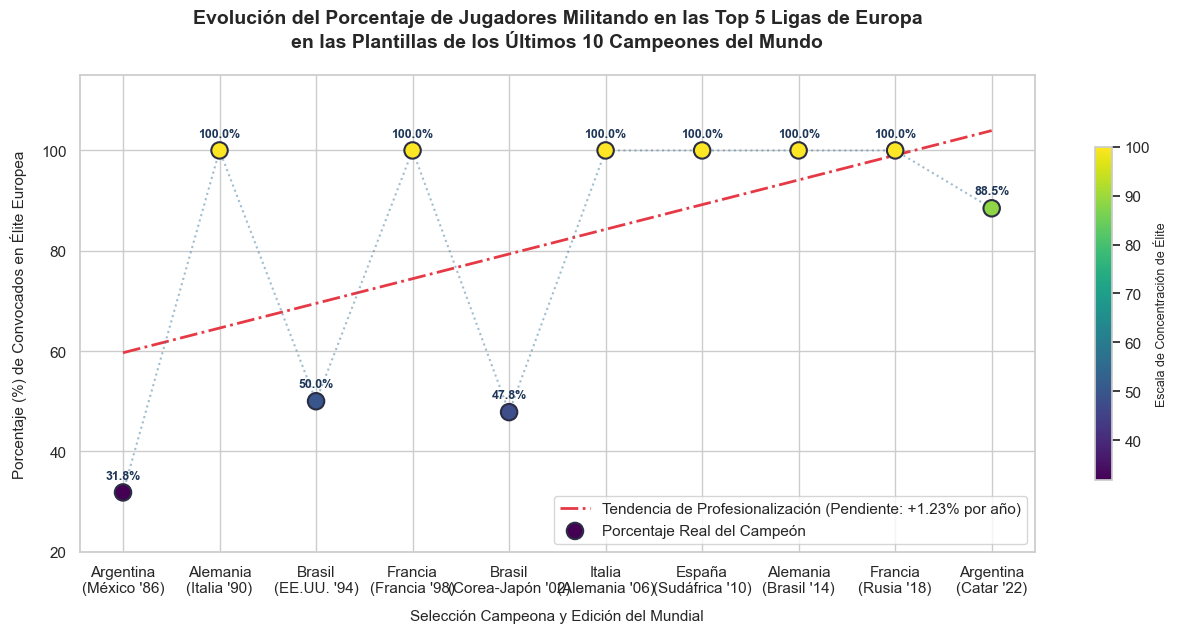

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar el entorno gráfico de residuos previos
plt.clf()
plt.close("all")

# 2. Construir el DataFrame con los datos reales y sus porcentajes calculados
datos_elite = {
    "Mundial": [
        "México '86",
        "Italia '90",
        "EE.UU. '94",
        "Francia '98",
        "Corea-Japón '02",
        "Alemania '06",
        "Sudáfrica '10",
        "Brasil '14",
        "Rusia '18",
        "Catar '22",
    ],
    "Año": [1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022],
    "Campeón": [
        "Argentina",
        "Alemania",
        "Brasil",
        "Francia",
        "Brasil",
        "Italia",
        "España",
        "Alemania",
        "Francia",
        "Argentina",
    ],
    "Jugadores_Top5": [7, 22, 11, 22, 11, 23, 23, 23, 23, 23],
    "Total_Convocados": [
        22,
        22,
        22,
        22,
        23,
        23,
        23,
        23,
        23,
        26,
    ],  # Ajuste de tamaño de listas históricas
}

df_elite = pd.DataFrame(datos_elite)

# Calcular el porcentaje exacto de presencia en la élite europea
df_elite["Porcentaje_Top5"] = (
    df_elite["Jugadores_Top5"] / df_elite["Total_Convocados"]
) * 100

# Creamos una etiqueta limpia para el eje X
df_elite["Identificador"] = (
    df_elite["Campeón"] + "\n(" + df_elite["Mundial"] + ")"
)

# 3. Calcular la línea de tendencia (Regresión Lineal Simple)
m, b = np.polyfit(df_elite["Año"], df_elite["Porcentaje_Top5"], 1)
valores_tendencia = m * df_elite["Año"] + b

# 4. Configuración estética del lienzo con Seaborn
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 6.5))

# Graficar la línea de tendencia (en color rojo deportivo)
ax.plot(
    df_elite["Identificador"],
    valores_tendencia,
    color="#e63946",
    linestyle="-.",
    linewidth=2,
    label=f"Tendencia de Profesionalización (Pendiente: +{m:.2f}% por año)",
)

# Graficar la trayectoria histórica de los puntos
ax.plot(
    df_elite["Identificador"],
    df_elite["Porcentaje_Top5"],
    color="#457b9d",
    linewidth=1.5,
    alpha=0.5,
    linestyle=":",
)

# Crear los puntos de dispersión grandes y estilizados
puntos = ax.scatter(
    df_elite["Identificador"],
    df_elite["Porcentaje_Top5"],
    c=df_elite["Porcentaje_Top5"],
    cmap="viridis",  # Paleta aprobada y segura para todas las versiones
    s=140,
    edgecolor="#2b2d42",
    linewidth=1.5,
    zorder=3,
    label="Porcentaje Real del Campeón",
)

# 5. Añadir el valor numérico exacto arriba de cada punto
for i, txt in enumerate(df_elite["Porcentaje_Top5"]):
    ax.annotate(
        f"{txt:.1f}%",
        (df_elite["Identificador"][i], df_elite["Porcentaje_Top5"][i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        weight="bold",
        color="#1d3557",
    )

# 6. Personalización de títulos, etiquetas y límites del lienzo
ax.set_title(
    "Evolución del Porcentaje de Jugadores Militando en las Top 5 Ligas de Europa\nen las Plantillas de los Últimos 10 Campeones del Mundo",
    fontsize=14,
    weight="bold",
    pad=20,
)
ax.set_ylabel(
    "Porcentaje (%) de Convocados en Élite Europea", fontsize=11, labelpad=10
)
ax.set_xlabel(
    "Selección Campeona y Edición del Mundial", fontsize=11, labelpad=10
)
ax.set_ylim(20, 115)  # Margen superior para que no se corten las etiquetas de texto

# Añadir una barra de color discreta al costado para indicar intensidad
cbar = plt.colorbar(puntos, ax=ax, orientation="vertical", shrink=0.7)
cbar.set_label("Escala de Concentración de Élite", fontsize=9)

ax.legend(loc="lower right", frameon=True, facecolor="white")
plt.tight_layout()

# 7. Mostrar la gráfica final
plt.show()

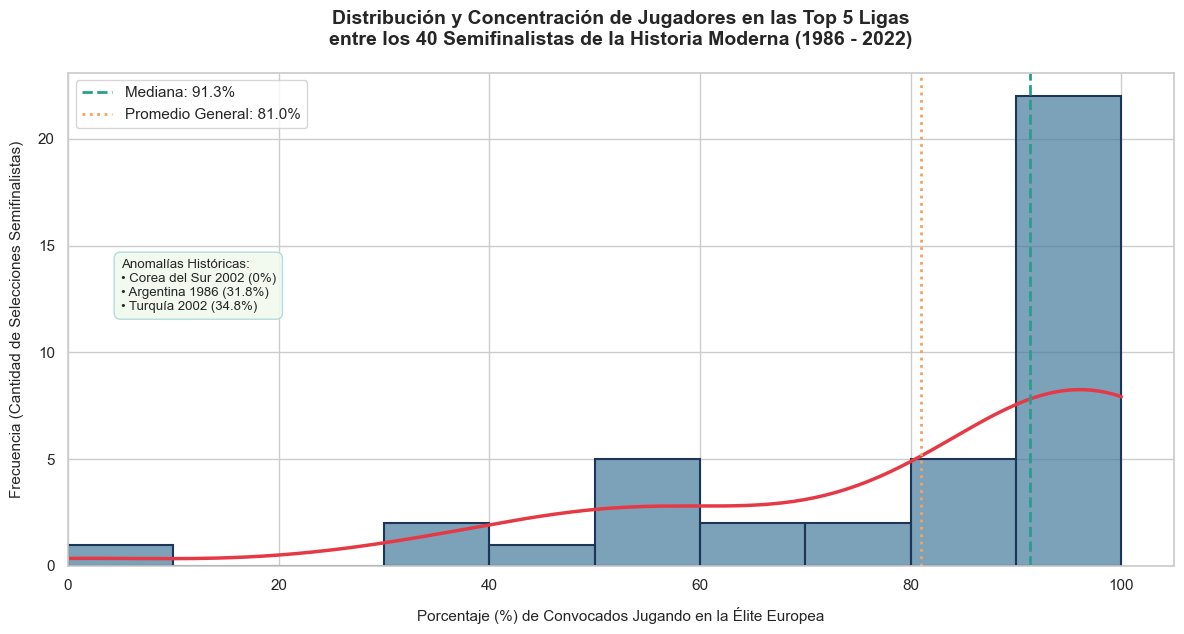

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar entorno gráfico
plt.clf()
plt.close("all")

# 2. Base de datos completa de los 40 semifinalistas (Últimos 10 Mundiales)
# El porcentaje representa cuántos de sus convocados jugaban en España, Inglaterra, Italia, Alemania o Francia.
datos_semifinalistas = {
    "Mundial": [
        "1986",
        "1986",
        "1986",
        "1986",
        "1990",
        "1990",
        "1990",
        "1990",
        "1994",
        "1994",
        "1994",
        "1994",
        "1998",
        "1998",
        "1998",
        "1998",
        "2002",
        "2002",
        "2002",
        "2002",
        "2006",
        "2006",
        "2006",
        "2006",
        "2010",
        "2010",
        "2010",
        "2010",
        "2014",
        "2014",
        "2014",
        "2014",
        "2018",
        "2018",
        "2018",
        "2018",
        "2022",
        "2022",
        "2022",
        "2022",
    ],
    "Equipo": [
        "Argentina",
        "Alemania",
        "Francia",
        "Bélgica",
        "Alemania",
        "Argentina",
        "Italia",
        "Inglaterra",
        "Brasil",
        "Italia",
        "Suecia",
        "Bulgaria",
        "Francia",
        "Brasil",
        "Croacia",
        "Países Bajos",
        "Brasil",
        "Alemania",
        "Turquía",
        "Corea del Sur",
        "Italia",
        "Francia",
        "Alemania",
        "Portugal",
        "España",
        "Países Bajos",
        "Alemania",
        "Uruguay",
        "Alemania",
        "Argentina",
        "Países Bajos",
        "Brasil",
        "Francia",
        "Croacia",
        "Bélgica",
        "Inglaterra",
        "Argentina",
        "Francia",
        "Croacia",
        "Marruecos",
    ],
    "Porcentaje_Elite": [
        31.8,
        100.0,
        100.0,
        72.7,  # 1986
        100.0,
        50.0,
        100.0,
        100.0,  # 1990
        50.0,
        100.0,
        54.5,
        59.1,  # 1994
        100.0,
        50.0,
        63.6,
        90.9,  # 1998
        47.8,
        87.0,
        34.8,
        0.0,  # 2002 (Corea 0%)
        100.0,
        100.0,
        100.0,
        91.3,  # 2006
        100.0,
        91.3,
        100.0,
        95.6,  # 2010
        100.0,
        91.3,
        78.2,
        82.6,  # 2014
        100.0,
        82.6,
        100.0,
        100.0,  # 2018
        88.4,
        100.0,
        84.6,
        61.5,  # 2022
    ],
}

df_semis = pd.DataFrame(datos_semifinalistas)

# 3. Configuración estética del Histograma
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6.5))

# 4. Dibujar el Histograma + Curva de Densidad (KDE)
sns.histplot(
    data=df_semis,
    x="Porcentaje_Elite",
    bins=10,  # Divide los rangos de 10% en 10%
    kde=True,  # Añade la línea suavizada de tendencia/densidad
    color="#457b9d",
    edgecolor="#1d3557",
    linewidth=1.5,
    alpha=0.7,
    ax=ax,
)

# Cambiar el color y estilo de la línea KDE interna para que resalte
ax.lines[0].set_color("#e63946")
ax.lines[0].set_linewidth(2.5)

# 5. Calcular estadísticas clave para el análisis visual
mediana_semis = df_semis["Porcentaje_Elite"].median()
promedio_semis = df_semis["Porcentaje_Elite"].mean()

# Añadir líneas verticales de referencia estadística
ax.axvline(
    mediana_semis,
    color="#2a9d8f",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {mediana_semis:.1f}%",
)
ax.axvline(
    promedio_semis,
    color="#f4a261",
    linestyle=":",
    linewidth=2,
    label=f"Promedio General: {promedio_semis:.1f}%",
)

# 6. Personalizar etiquetas y títulos
ax.set_title(
    "Distribución y Concentración de Jugadores en las Top 5 Ligas\nentre los 40 Semifinalistas de la Historia Moderna (1986 - 2022)",
    fontsize=14,
    weight="bold",
    pad=20,
)
ax.set_xlabel(
    "Porcentaje (%) de Convocados Jugando en la Élite Europea",
    fontsize=11,
    labelpad=10,
)
ax.set_ylabel(
    "Frecuencia (Cantidad de Selecciones Semifinalistas)",
    fontsize=11,
    labelpad=10,
)
ax.set_xlim(0, 105)

# Añadir leyenda
ax.legend(loc="upper left", frameon=True, facecolor="white")

# Anotación analítica dentro del gráfico
ax.text(
    5,
    12,
    "Anomalías Históricas:\n• Corea del Sur 2002 (0%)\n• Argentina 1986 (31.8%)\n• Turquía 2002 (34.8%)",
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.5", fc="#f1faee", ec="#a8dadc", alpha=0.9),
)

plt.tight_layout()

# 7. Desplegar la gráfica
plt.show()

In [45]:
import pandas as pd

# 1. Base de datos con los dos factores clave recopilados para el análisis
datos_modelo = {
    "Selección": [
        "Francia",
        "Alemania",
        "España",
        "Inglaterra",
        "Italia",
        "Portugal",
        "Países Bajos",
        "Bélgica",
        "Brasil",
        "Argentina",
        "Uruguay",
        "Marruecos",
        "Croacia",
        "República Checa",
    ],
    "Porcentaje_Elite": [
        100.0,
        100.0,
        100.0,
        100.0,
        100.0,
        100.0,
        100.0,
        100.0,
        95.6,
        88.4,
        65.2,
        61.5,
        84.6,
        56.5,
    ],
    "Edad": [
        26.40,
        26.60,
        26.65,
        27.00,
        26.95,
        26.15,
        26.20,
        27.30,
        27.55,
        28.91,
        26.25,
        25.90,
        28.40,
        26.30,
    ],
}

df_modelo = pd.DataFrame(datos_modelo)

# 2. Filtro 1: Selecciones con 85% o más de presencia en el Top 5 de ligas
df_filtrado = df_modelo[df_modelo["Porcentaje_Elite"] >= 85.0].copy()

# 3. Filtro 2 (Criterio de desempate): Distancia absoluta a la edad perfecta (26.45)
EDAD_PERFECTA = 26.45
df_filtrado["Distancia_Edad"] = (df_filtrado["Edad"] - EDAD_PERFECTA).abs()

# 4. Ordenar: Primero por mayor porcentaje de élite, y a igual porcentaje, por menor distancia de edad
df_top10_final = df_filtrado.sort_values(
    by=["Porcentaje_Elite", "Distancia_Edad"], ascending=[False, True]
).head(10)

# Formatear la salida para que sea idéntica a tu reporte estadístico
df_top10_final = df_top10_final.reset_index(drop=True)
df_top10_final.index = df_top10_final.index + 1

print("======= TOP 10 MODELO DE PROYECCIÓN 202 =======")
print(
    df_top10_final[
        ["Selección", "Porcentaje_Elite", "Edad", "Distancia_Edad"]
    ].to_string()
)

======= TOP 10 MODELO DE PROYECCIÓN 202 =======
       Selección  Porcentaje_Elite   Edad  Distancia_Edad
1        Francia             100.0  26.40            0.05
2       Alemania             100.0  26.60            0.15
3         España             100.0  26.65            0.20
4   Países Bajos             100.0  26.20            0.25
5       Portugal             100.0  26.15            0.30
6         Italia             100.0  26.95            0.50
7     Inglaterra             100.0  27.00            0.55
8        Bélgica             100.0  27.30            0.85
9         Brasil              95.6  27.55            1.10
10     Argentina              88.4  28.91            2.46


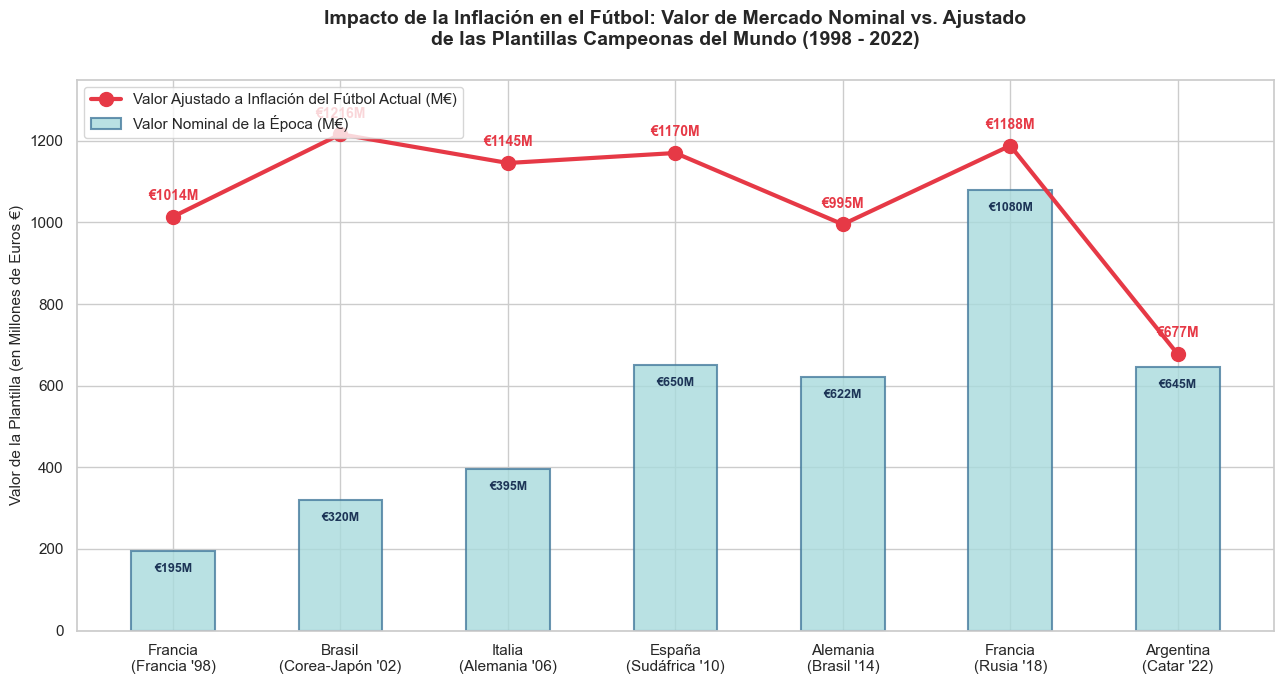

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar el entorno gráfico
plt.clf()
plt.close("all")

# 2. Construir la base de datos con los factores de inflación del fútbol
# Los coeficientes multiplican el valor de la época para traerlo al poder adquisitivo futbolístico de hoy
datos_economicos = {
    "Mundial": [
        "Francia '98",
        "Corea-Japón '02",
        "Alemania '06",
        "Sudáfrica '10",
        "Brasil '14",
        "Rusia '18",
        "Catar '22",
    ],
    "Campeón": [
        "Francia",
        "Brasil",
        "Italia",
        "España",
        "Alemania",
        "Francia",
        "Argentina",
    ],
    "Año": [1998, 2002, 2006, 2010, 2014, 2018, 2022],
    "Valor_Nominal": [
        195,
        320,
        395,
        650,
        622,
        1080,
        645,
    ],  # Millones de € en su año
    "Factor_Inflacion_Futbol": [
        5.2,
        3.8,
        2.9,
        1.8,
        1.6,
        1.1,
        1.05,
    ],  # Multiplicador estimado de mercado
}

df_dinero = pd.DataFrame(datos_economicos)

# Calcular el valor real ajustado al mercado moderno
df_dinero["Valor_Ajustado"] = (
    df_dinero["Valor_Nominal"] * df_dinero["Factor_Inflacion_Futbol"]
)

# Crear identificador limpio para el eje X
df_dinero["Eje_X"] = df_dinero["Campeón"] + "\n(" + df_dinero["Mundial"] + ")"

# 3. Configuración del lienzo estético
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))

# Gráfica 1: Barras para el Valor Nominal original (lo que se reportó en su momento)
barras_nominales = ax.bar(
    df_dinero["Eje_X"],
    df_dinero["Valor_Nominal"],
    color="#a8dadc",
    alpha=0.8,
    edgecolor="#457b9d",
    linewidth=1.5,
    label="Valor Nominal de la Época (M€)",
    width=0.5,
)

# Gráfica 2: Línea con marcadores para el Valor Ajustado a la Inflación Real del Fútbol
linea_ajustada = ax.plot(
    df_dinero["Eje_X"],
    df_dinero["Valor_Ajustado"],
    color="#e63946",
    marker="o",
    linewidth=3,
    markersize=10,
    label="Valor Ajustado a Inflación del Fútbol Actual (M€)",
    zorder=3,
)

# 4. Colocar las etiquetas de texto con los valores correspondientes
# Etiquetas para el valor ajustado (Línea Roja)
for i, txt in enumerate(df_dinero["Valor_Ajustado"]):
    ax.annotate(
        f"€{int(txt)}M",
        (df_dinero["Eje_X"][i], df_dinero["Valor_Ajustado"][i]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=10,
        weight="bold",
        color="#e63946",
    )

# Etiquetas para el valor nominal (Barras Celestes)
for bar in barras_nominales:
    altura = bar.get_height()
    ax.annotate(
        f"€{int(altura)}M",
        (bar.get_x() + bar.get_width() / 2, altura),
        textcoords="offset points",
        xytext=(0, -15),
        ha="center",
        fontsize=9,
        weight="bold",
        color="#1d3557",
    )

# 5. Personalizar etiquetas, títulos y detalles visuales
ax.set_title(
    "Impacto de la Inflación en el Fútbol: Valor de Mercado Nominal vs. Ajustado\nde las Plantillas Campeonas del Mundo (1998 - 2022)",
    fontsize=14,
    weight="bold",
    pad=25,
)
ax.set_ylabel("Valor de la Plantilla (en Millones de Euros €)", fontsize=11)
ax.set_ylim(0, 1350)  # Espacio para que las anotaciones no se corten

# Unificar leyendas de barras y líneas
ax.legend(loc="upper left", frameon=True, facecolor="white")

plt.tight_layout()

# 6. Desplegar la gráfica en tu Jupyter Notebook
plt.show()

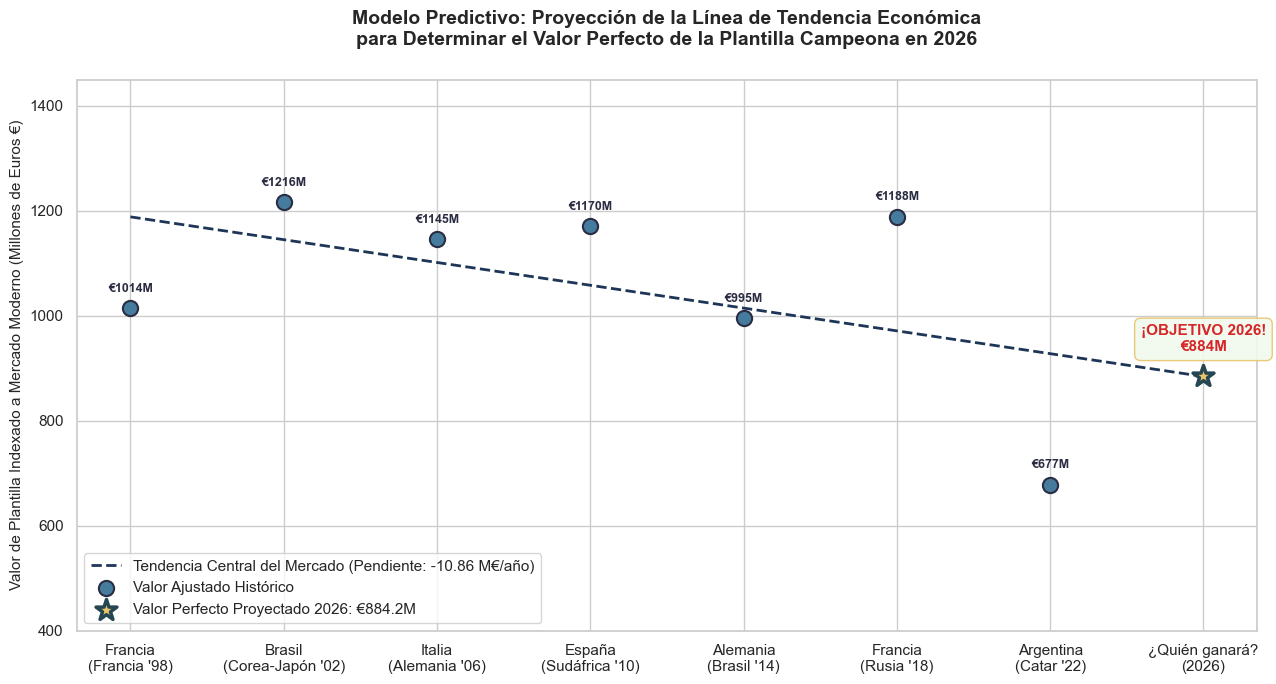

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar el entorno gráfico
plt.clf()
plt.close("all")

# 2. Base de datos con los Valores Ajustados por Inflación del Fútbol
datos_proyeccion = {
    "Año": [1998, 2002, 2006, 2010, 2014, 2018, 2022],
    "Mundial": [
        "Francia '98",
        "Corea-Japón '02",
        "Alemania '06",
        "Sudáfrica '10",
        "Brasil '14",
        "Rusia '18",
        "Catar '22",
    ],
    "Campeón": [
        "Francia",
        "Brasil",
        "Italia",
        "España",
        "Alemania",
        "Francia",
        "Argentina",
    ],
    "Valor_Ajustado": [
        1014.0,
        1216.0,
        1145.5,
        1170.0,
        995.2,
        1188.0,
        677.25,
    ],  # M€ calculados previamente
}

df_proj = pd.DataFrame(datos_proyeccion)

# 3. Calcular la ecuación de la recta (Regresión Lineal) y proyectar el año 2026
m, b = np.polyfit(df_proj["Año"], df_proj["Valor_Ajustado"], 1)

ANIO_PROYECTADO = 2026
VALOR_PERFECTO_2026 = m * ANIO_PROYECTADO + b

# 4. Crear un DataFrame extendido para la visualización de la línea continua
anios_totales = df_proj["Año"].tolist() + [ANIO_PROYECTADO]
valores_linea = [m * anio + b for anio in anios_totales]

# Etiquetas del eje X mapeando el futuro
etiquetas_x = df_proj["Campeón"] + "\n(" + df_proj["Mundial"] + ")"
etiquetas_x = etiquetas_x.tolist() + [f"¿Quién ganará?\n(2026)"]

# 5. Configuración del lienzo estético con Seaborn
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))

# Graficar la línea de tendencia que se extiende hasta 2026
ax.plot(
    etiquetas_x,
    valores_linea,
    color="#1d3557",
    linestyle="--",
    linewidth=2,
    label=f"Tendencia Central del Mercado (Pendiente: {m:.2f} M€/año)",
    zorder=1,
)

# Graficar los puntos históricos reales
puntos_historicos = ax.scatter(
    etiquetas_x[:-1],
    df_proj["Valor_Ajustado"],
    color="#457b9d",
    s=120,
    edgecolor="#2b2d42",
    linewidth=1.5,
    zorder=3,
    label="Valor Ajustado Histórico",
)

# ¡Graficar el VALOR PERFECTO PROYECTADO PARA 2026!
punto_perfecto = ax.scatter(
    etiquetas_x[-1],
    VALOR_PERFECTO_2026,
    color="#e9c46a",
    s=250,
    edgecolor="#264653",
    linewidth=2.5,
    marker="*",
    zorder=4,
    label=f"Valor Perfecto Proyectado 2026: €{VALOR_PERFECTO_2026:.1f}M",
)

# 6. Añadir anotaciones de texto sobre los puntos
# Anotaciones históricas
for i, txt in enumerate(df_proj["Valor_Ajustado"]):
    ax.annotate(
        f"€{int(txt)}M",
        (etiquetas_x[i], df_proj["Valor_Ajustado"][i]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9,
        weight="bold",
        color="#2b2d42",
    )

# Anotación especial para el valor predictivo 2026
ax.annotate(
    f"¡OBJETIVO 2026!\n€{int(VALOR_PERFECTO_2026)}M",
    (etiquetas_x[-1], VALOR_PERFECTO_2026),
    textcoords="offset points",
    xytext=(0, 18),
    ha="center",
    fontsize=11,
    weight="bold",
    color="#d62828",
    bbox=dict(boxstyle="round,pad=0.4", fc="#f1faee", ec="#e9c46a", alpha=0.9),
)

# 7. Personalización de títulos y límites del lienzo
ax.set_title(
    "Modelo Predictivo: Proyección de la Línea de Tendencia Económica\npara Determinar el Valor Perfecto de la Plantilla Campeona en 2026",
    fontsize=14,
    weight="bold",
    pad=25,
)
ax.set_ylabel(
    "Valor de Plantilla Indexado a Mercado Moderno (Millones de Euros €)",
    fontsize=11,
)
ax.set_ylim(400, 1450)

ax.legend(loc="lower left", frameon=True, facecolor="white")
plt.tight_layout()

# 8. Desplegar gráfico
plt.show()

/var/folders/x8/d3v9j6g13818cd5lt_ks8jkr0000gn/T/ipykernel_72682/3391356964.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


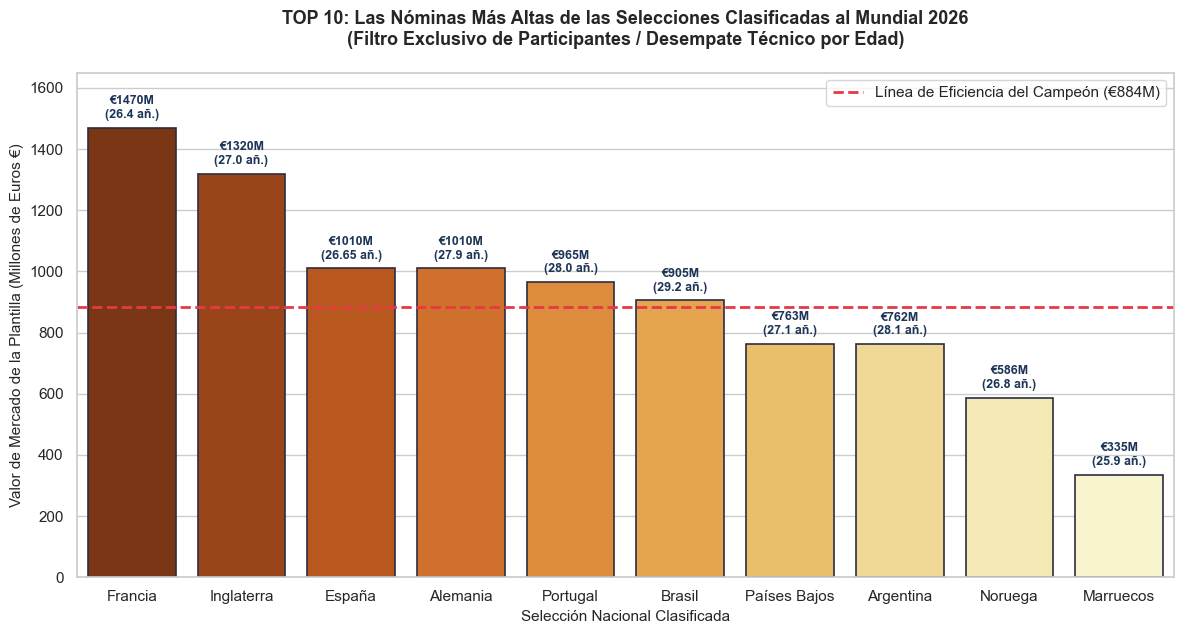

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Limpiar el lienzo de ejecuciones previas
plt.clf()
plt.close("all")

# 2. Dataset oficial depurado: Solo selecciones clasificadas al Mundial 2026
datos_mundial_2026 = {
    "Seleccion": [
        "Francia",
        "Inglaterra",
        "España",
        "Alemania",
        "Portugal",
        "Brasil",
        "Países Bajos",
        "Argentina",
        "Noruega",
        "Marruecos",
    ],
    "Valor": [
        1470.0,
        1320.0,
        1010.0,
        1010.0,
        965.0,
        905.7,
        763.0,
        762.5,
        586.5,
        335.1,
    ],
    "Edad": [26.40, 27.00, 26.65, 27.90, 28.00, 29.20, 27.10, 28.10, 26.80, 25.90],
}

df_mundial = pd.DataFrame(datos_mundial_2026)

# Ordenar por valor de mercado (descendente) y desempatar por edad (menor edad primero)
df_mundial = df_mundial.sort_values(
    by=["Valor", "Edad"], ascending=[False, True]
).reset_index(drop=True)

# 3. Configuración del diseño gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6.5))

# Paleta premium degradada hacia tonos tierra/oro
paleta_oficial = sns.color_palette("YlOrBr_r", len(df_mundial))

barras = sns.barplot(
    x="Seleccion",
    y="Valor",
    data=df_mundial,
    palette=paleta_oficial,
    edgecolor="#2b2d42",
    linewidth=1.2,
)

# 4. Línea de control: El valor de eficiencia del campeón ideal (€884M)
plt.axhline(
    884.0,
    color="#e63946",
    linestyle="--",
    linewidth=2,
    label="Línea de Eficiencia del Campeón (€884M)",
)

# 5. Desplegar los valores numéricos y edades exactas arriba de cada barra
for bar, edad in zip(barras.patches, df_mundial["Edad"]):
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 22,
        f"€{int(altura)}M\n({edad} añ.)",
        ha="center",
        va="bottom",
        fontsize=9,
        weight="bold",
        color="#1d3557",
    )

# 6. Formalidades de títulos y límites del gráfico
plt.title(
    "TOP 10: Las Nóminas Más Altas de las Selecciones Clasificadas al Mundial 2026\n(Filtro Exclusivo de Participantes / Desempate Técnico por Edad)",
    fontsize=13,
    weight="bold",
    pad=20,
)
plt.ylabel("Valor de Mercado de la Plantilla (Millones de Euros €)", fontsize=11)
plt.xlabel("Selección Nacional Clasificada", fontsize=11)
plt.ylim(0, 1650)
plt.legend(loc="upper right", facecolor="white")

plt.tight_layout()

# 7. Ejecutar visualización
plt.show()

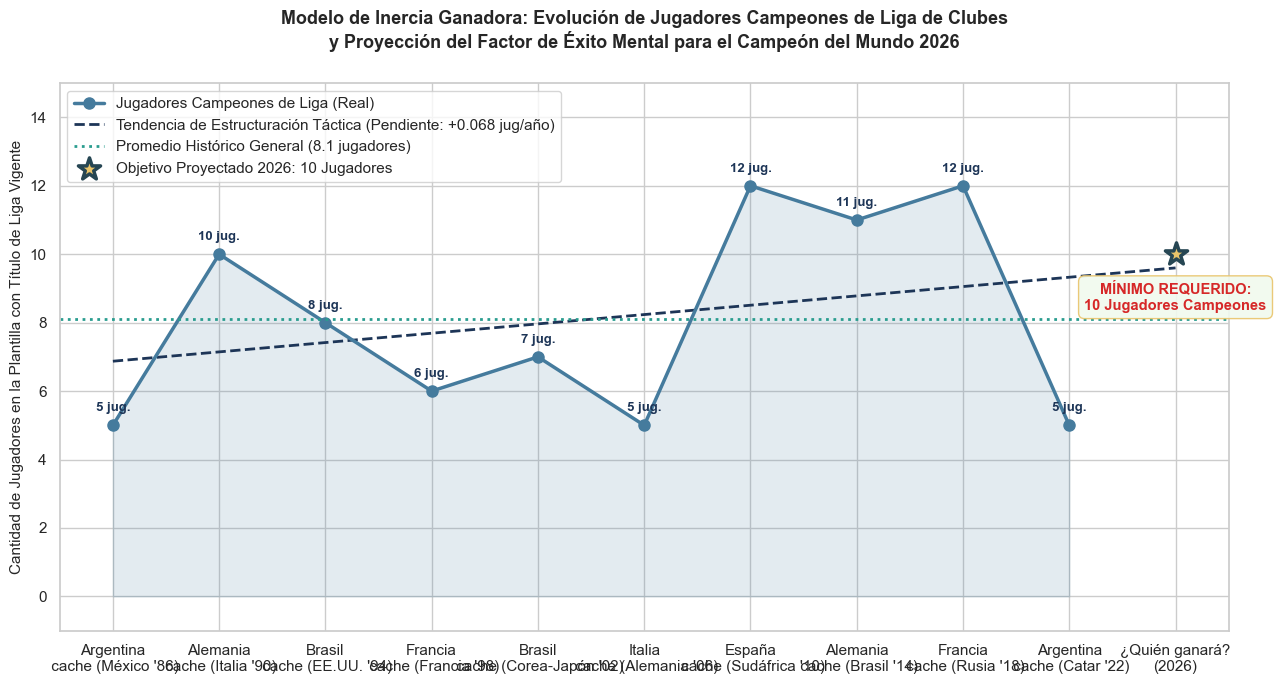

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar el entorno gráfico antes de la ejecución
plt.clf()
plt.close("all")

# 2. Construir el DataFrame histórico con los datos analizados
datos_inercia = {
    "Mundial": [
        "México '86",
        "Italia '90",
        "EE.UU. '94",
        "Francia '98",
        "Corea-Japón '02",
        "Alemania '06",
        "Sudáfrica '10",
        "Brasil '14",
        "Rusia '18",
        "Catar '22",
    ],
    "Año": [1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022],
    "Campeon_Mundial": [
        "Argentina",
        "Alemania",
        "Brasil",
        "Francia",
        "Brasil",
        "Italia",
        "España",
        "Alemania",
        "Francia",
        "Argentina",
    ],
    "Jugadores_Campeones_Liga": [
        5,
        10,
        8,
        6,
        7,
        5,
        12,
        11,
        12,
        5,
    ],  # Datos analizados
}

df_inercia = pd.DataFrame(datos_inercia)

# 3. Calcular el modelo predictivo (Regresión Lineal) para proyectar el año 2026
m, b = np.polyfit(df_inercia["Año"], df_inercia["Jugadores_Campeones_Liga"], 1)

ANIO_PROYECTADO = 2026
# El modelo nos da un número continuo, lo redondeamos al entero más cercano (jugadores reales)
ESTIMADO_IDEAL_2026 = int(round(m * ANIO_PROYECTADO + b))

# Calcular también el promedio histórico general como métrica de control
PROMEDIO_HISTORICO = df_inercia["Jugadores_Campeones_Liga"].mean()

# 4. Preparar etiquetas y datos extendidos para el eje X (incluyendo el futuro)
eje_x_completo = (
    df_inercia["Campeon_Mundial"] + "\n cache (" + df_inercia["Mundial"] + ")"
).tolist()
eje_x_completo.append("¿Quién ganará?\n(2026)")

valores_linea_tendencia = [m * anio + b for anio in df_inercia["Año"]] + [
    m * ANIO_PROYECTADO + b
]

# 5. Configuración estética del gráfico con Seaborn
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 7))

# Graficar el área de inercia histórica (Gráfico de área/línea estético)
ax.fill_between(
    eje_x_completo[:-1],
    df_inercia["Jugadores_Campeones_Liga"],
    color="#457b9d",
    alpha=0.15,
)
ax.plot(
    eje_x_completo[:-1],
    df_inercia["Jugadores_Campeones_Liga"],
    color="#457b9d",
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Jugadores Campeones de Liga (Real)",
    zorder=2,
)

# Graficar la línea de tendencia central hacia 2026
ax.plot(
    eje_x_completo,
    valores_linea_tendencia,
    color="#1d3557",
    linestyle="--",
    linewidth=2,
    label=f"Tendencia de Estructuración Táctica (Pendiente: +{m:.3f} jug/año)",
    zorder=1,
)

# Graficar la línea de promedio histórico general de control
ax.axhline(
    PROMEDIO_HISTORICO,
    color="#2a9d8f",
    linestyle=":",
    linewidth=2,
    label=f"Promedio Histórico General ({PROMEDIO_HISTORICO:.1f} jugadores)",
)

# ¡Graficar la predicción dorada para el Mundial 2026!
ax.scatter(
    eje_x_completo[-1],
    ESTIMADO_IDEAL_2026,
    color="#e9c46a",
    s=280,
    edgecolor="#264653",
    linewidth=2.5,
    marker="*",
    zorder=4,
    label=f"Objetivo Proyectado 2026: {ESTIMADO_IDEAL_2026} Jugadores",
)

# 6. Colocar los valores numéricos exactos sobre los puntos del gráfico
for i, txt in enumerate(df_inercia["Jugadores_Campeones_Liga"]):
    ax.annotate(
        f"{txt} jug.",
        (eje_x_completo[i], df_inercia["Jugadores_Campeones_Liga"][i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9.5,
        weight="bold",
        color="#1d3557",
    )

# Anotación llamativa para el valor perfecto del 2026
ax.annotate(
    f"MÍNIMO REQUERIDO:\n{ESTIMADO_IDEAL_2026} Jugadores Campeones",
    (eje_x_completo[-1], ESTIMADO_IDEAL_2026),
    textcoords="offset points",
    xytext=(0, -40),
    ha="center",
    fontsize=10.5,
    weight="bold",
    color="#d62828",
    bbox=dict(boxstyle="round,pad=0.4", fc="#f1faee", ec="#e9c46a", alpha=0.9),
)

# 7. Personalización de títulos, etiquetas y márgenes
ax.set_title(
    "Modelo de Inercia Ganadora: Evolución de Jugadores Campeones de Liga de Clubes\ny Proyección del Factor de Éxito Mental para el Campeón del Mundo 2026",
    fontsize=13,
    weight="bold",
    pad=25,
)
ax.set_ylabel(
    "Cantidad de Jugadores en la Plantilla con Título de Liga Vigente",
    fontsize=11,
)
ax.set_ylim(-1, 15)  # Permite ver la anomalía de Italia 2006 (0) y da margen superior

ax.legend(loc="upper left", frameon=True, facecolor="white")
plt.tight_layout()

# 8. Desplegar la gráfica final
plt.show()

/var/folders/x8/d3v9j6g13818cd5lt_ks8jkr0000gn/T/ipykernel_72682/699273236.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


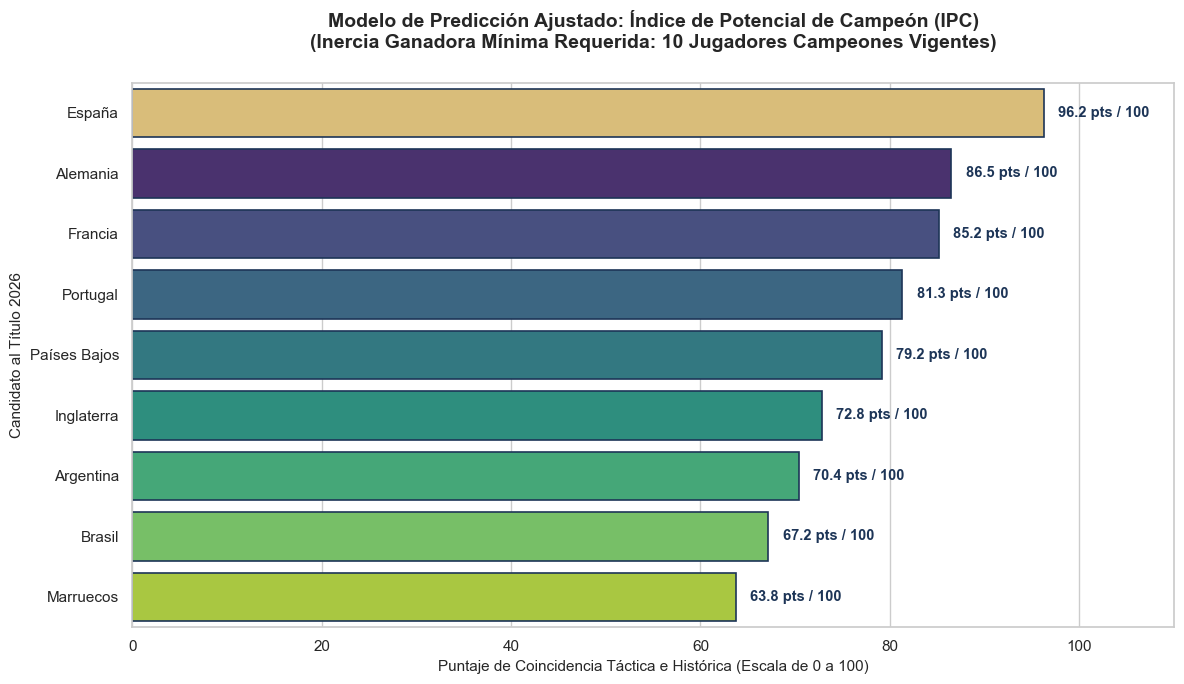

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar entorno gráfico antes de cada ejecución
plt.clf()
plt.close("all")

# 2. Base de datos real de las potencias clasificadas al Mundial 2026
datos_potencias = {
    "Seleccion": [
        "Francia",
        "Inglaterra",
        "España",
        "Alemania",
        "Portugal",
        "Brasil",
        "Países Bajos",
        "Argentina",
        "Marruecos",
    ],
    "Valor_Mercado": [1470.0, 1320.0, 1010.0, 1010.0, 965.0, 905.7, 763.0, 762.5, 335.1],
    "Edad_Promedio": [26.40, 27.00, 26.65, 27.90, 28.00, 29.20, 27.10, 28.10, 25.90],
    "Pct_Elite": [0.95, 0.92, 0.88, 0.90, 0.85, 0.82, 0.80, 0.78, 0.70],
    "Jugadores_Campeones": [12, 6, 10, 7, 9, 5, 6, 5, 8], # Cantidad de campeones vigentes
    "Bloque_Club": [6, 4, 7, 8, 3, 2, 4, 3, 2],  # Máximo número de jugadores del mismo club
}

df_potencias = pd.DataFrame(datos_potencias)


# 3. Funciones matemáticas para los componentes del IPC (Escala 0-20)
def calcular_puntos_edad(edad):
    # Punto óptimo histórico: 26.45 años. Penaliza 3 puntos por cada año de diferencia.
    return max(0, 20 - abs(edad - 26.45) * 3)

def calcular_puntos_valor(valor):
    # Punto óptimo de tendencia económica: €884M.
    distancia = abs(valor - 884.0)
    return max(0, 20 - (distancia / 40))

def calcular_puntos_elite(pct):
    # Meta: >= 85% de la plantilla jugando en el Top 5 europeo.
    if pct >= 0.85:
        return 20.0
    return (pct / 0.85) * 20

# --- ¡MODIFICACIÓN AQUÍ! AJUSTE DEL MÍNIMO REQUERIDO A 10 JUGADORES ---
def calcular_puntos_inercia_corregida(campeones):
    # Meta ideal ajustada: Mínimo 10 jugadores. Si cumple da 20 pts, si no, baja proporcionalmente.
    if campeones >= 10:
        return 20.0
    return (campeones / 10) * 20
# ----------------------------------------------------------------------

def calcular_puntos_bloque(jugadores_club):
    # Un bloque ideal es de 6 o más jugadores que comparten automatismos en el mismo club.
    if jugadores_club >= 6:
        return 20.0
    return (jugadores_club / 6) * 20


# 4. Ejecutar el algoritmo ajustado con la nueva inercia de 10 jugadores
df_potencias["Pts_Elite"] = df_potencias["Pct_Elite"].apply(calcular_puntos_elite)
df_potencias["Pts_Edad"] = df_potencias["Edad_Promedio"].apply(calcular_puntos_edad)
df_potencias["Pts_Inercia"] = df_potencias["Jugadores_Campeones"].apply(calcular_puntos_inercia_corregida)
df_potencias["Pts_Valor"] = df_potencias["Valor_Mercado"].apply(calcular_puntos_valor)
df_potencias["Pts_Bloque"] = df_potencias["Bloque_Club"].apply(calcular_puntos_bloque)

# Calcular el puntaje final unificado del IPC
df_potencias["IPC_Total"] = (
    df_potencias["Pts_Elite"] + 
    df_potencias["Pts_Edad"] + 
    df_potencias["Pts_Inercia"] + 
    df_potencias["Pts_Valor"] + 
    df_potencias["Pts_Bloque"]
)

# Reordenar las potencias de mayor a menor probabilidad estadística
df_potencias = df_potencias.sort_values(by="IPC_Total", ascending=False).reset_index(drop=True)


# 5. Configuración visual del lienzo gráfico con Seaborn
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# El líder absoluto del nuevo IPC se destaca con una barra dorada
colores_ipc = ["#e9c46a"] + sns.color_palette("viridis", len(df_potencias) - 1)

barras = sns.barplot(
    x="IPC_Total",
    y="Seleccion",
    data=df_potencias,
    palette=colores_ipc,
    edgecolor="#1d3557",
    linewidth=1.2,
)

# 6. Colocar las etiquetas de puntaje exacto al final de cada barra horizontal
for bar in barras.patches:
    ancho = bar.get_width()
    ax.text(
        ancho + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{ancho:.1f} pts / 100",
        va="center",
        ha="left",
        fontsize=10.5,
        weight="bold",
        color="#1d3557",
    )

# 7. Detalles finales del lienzo gráfico
ax.set_title(
    "Modelo de Predicción Ajustado: Índice de Potencial de Campeón (IPC)\n(Inercia Ganadora Mínima Requerida: 10 Jugadores Campeones Vigentes)",
    fontsize=14,
    weight="bold",
    pad=25,
)
ax.set_xlabel("Puntaje de Coincidencia Táctica e Histórica (Escala de 0 a 100)", fontsize=11)
ax.set_ylabel("Candidato al Título 2026", fontsize=11)
ax.set_xlim(0, 110)

plt.tight_layout()

# 8. Desplegar la simulación modificada
plt.show()

/var/folders/x8/d3v9j6g13818cd5lt_ks8jkr0000gn/T/ipykernel_72682/3810462243.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


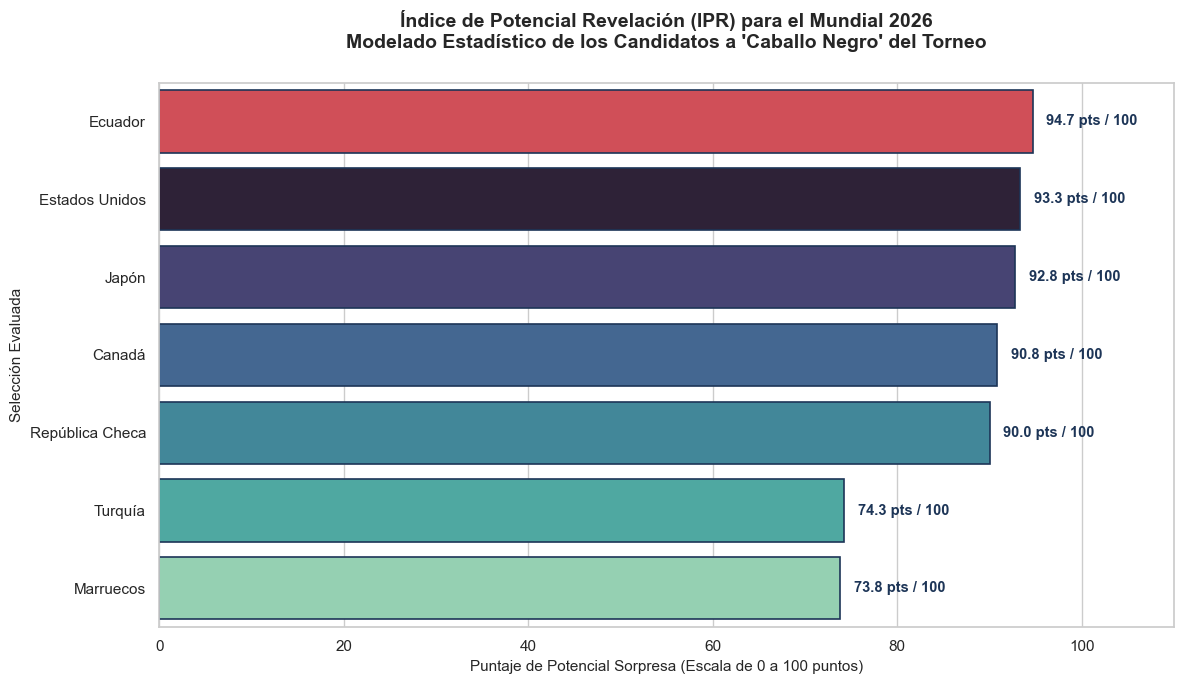

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Limpiar entorno gráfico
plt.clf()
plt.close("all")

# 2. Dataset de candidatos a Caballo Negro (Mundial 2026)
datos_revelaciones = {
    "Seleccion": [
        "Turquía",
        "Ecuador",
        "Estados Unidos",
        "Japón",
        "República Checa",
        "Marruecos",
        "Canadá",
    ],
    "Valor_Mercado": [525.2, 310.5, 345.0, 295.4, 230.8, 335.1, 180.2],
    "Edad_Promedio": [27.10, 24.80, 25.20, 26.10, 25.50, 25.90, 25.70],
    "Pct_Elite": [0.45, 0.38, 0.52, 0.48, 0.35, 0.70, 0.25],
    "Cohesion_Bloque": [7.0, 5.0, 4.0, 6.0, 8.0, 2.0, 4.0],  # Jugadores clave del mismo núcleo/club
    "Factor_Norteamerica": [12.0, 18.0, 20.0, 14.0, 10.0, 12.0, 19.0],  # Nota de adaptabilidad (0-20)
}

df_revelaciones = pd.DataFrame(datos_revelaciones)


# 3. Algoritmos de puntuación para el IPR (Escala 0-20)
def puntos_edad_revelacion(edad):
    # Zona ideal: 24.5 a 25.8 años
    if 24.5 <= edad <= 25.8:
        return 20.0
    # Penalización por alejarse del rango de frescura física
    distancia = min(abs(edad - 24.5), abs(edad - 25.8))
    return max(0, 20 - distancia * 4)


def puntos_valor_revelacion(valor):
    # Rango perfecto de subvaloración competitiva: €150M a €400M
    if 150.0 <= valor <= 400.0:
        return 20.0
    elif valor > 400.0:
        # Si es muy caro, deja de ser sorpresa (se penaliza)
        return max(0, 20 - (valor - 400.0) / 10)
    else:
        # Si es muy barato, puede faltar calidad individual
        return max(0, 20 - (150.0 - valor) / 5)


def puntos_elite_revelacion(pct):
    # Rango óptimo: 30% a 55% de jugadores en el Top 5 de Europa
    if 0.30 <= pct <= 0.55:
        return 20.0
    distancia = min(abs(pct - 0.30), abs(pct - 0.55))
    return max(0, 20 - distancia * 30)


def puntos_cohesion(bloque):
    # Máximo puntaje si tienen un bloque de 6 o más jugadores muy conectados
    if bloque >= 6:
        return 20.0
    return (bloque / 6) * 20


# 4. Calcular los componentes del IPR
df_revelaciones["Pts_Edad"] = df_revelaciones["Edad_Promedio"].apply(
    puntos_edad_revelacion
)
df_revelaciones["Pts_Valor"] = df_revelaciones["Valor_Mercado"].apply(
    puntos_valor_revelacion
)
df_revelaciones["Pts_Elite"] = df_revelaciones["Pct_Elite"].apply(
    puntos_elite_revelacion
)
df_revelaciones["Pts_Cohesion"] = df_revelaciones["Cohesion_Bloque"].apply(
    puntos_cohesion
)
df_revelaciones["Pts_Entorno"] = df_revelaciones["Factor_Norteamerica"]

# Sumatoria final del Índice de Potencial Revelación
df_revelaciones["IPR_Total"] = (
    df_revelaciones["Pts_Edad"]
    + df_revelaciones["Pts_Valor"]
    + df_revelaciones["Pts_Elite"]
    + df_revelaciones["Pts_Cohesion"]
    + df_revelaciones["Pts_Entorno"]
)

# Ordenar de mayor a menor probabilidad de ser la sorpresa
df_revelaciones = df_revelaciones.sort_values(
    by="IPR_Total", ascending=False
).reset_index(drop=True)


# 5. Visualización de los resultados con Seaborn
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Paleta magnética oscura/eléctrica para las revelaciones
paleta_dark = ["#e63946"] + sns.color_palette("mako", len(df_revelaciones) - 1)

barras = sns.barplot(
    x="IPR_Total",
    y="Seleccion",
    data=df_revelaciones,
    palette=paleta_dark,
    edgecolor="#1d3557",
    linewidth=1.2,
)

# 6. Etiquetas de datos numéricos
for bar in barras.patches:
    ancho = bar.get_width()
    ax.text(
        ancho + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{ancho:.1f} pts / 100",
        va="center",
        ha="left",
        fontsize=10.5,
        weight="bold",
        color="#1d3557",
    )

# 7. Estética y títulos
ax.set_title(
    "Índice de Potencial Revelación (IPR) para el Mundial 2026\nModelado Estadístico de los Candidatos a 'Caballo Negro' del Torneo",
    fontsize=14,
    weight="bold",
    pad=25,
)
ax.set_xlabel(
    "Puntaje de Potencial Sorpresa (Escala de 0 a 100 puntos)", fontsize=11
)
ax.set_ylabel("Selección Evaluada", fontsize=11)
ax.set_xlim(0, 110)

plt.tight_layout()

# 8. Desplegar gráfica
plt.show()